# PS-S5E12: CatBoost

This notebook tackles the [**Playground Series – Season 5, Episode 12: Diabetes Prediction Challenge**](https://www.kaggle.com/competitions/playground-series-s5e12), a competition focused on aiding medical diagnosis: predict if a patient will be diagnosed with diabetes.  The goal is to develop a model that can accurately predict whether a patient will be diagnosed with diabetes, based on a set of medical and demographic features.

## Introduction

**CatBoost** distinguishes itself with its native handling of categorical features, eliminating the need for extensive manual encoding (like One-Hot) often required by other gradient boosting libraries. It utilizes "Ordered Boosting" to combat target leakage and employs symmetric decision trees, which often leads to more robust generalization and faster inference speeds. This model is particularly effective when dealing with datasets containing a mix of numerical physiological markers and categorical demographic data without requiring complex preprocessing.
The notebook is one of a number of notebooks that explore various models to address this challenge.  The EDA for this dataset was performed in this notebook: [**PS-S5E12: EDA**](https://www.kaggle.com/code/stephentarter/ps-s5e12-eda).

## Install Needed Packages

In [1]:
%load_ext autoreload
%autoreload 2
    
import os
import gc
import sys
import math
import random
import warnings
from pathlib import Path
from typing import Iterable
from IPython.display import display, Markdown, IFrame

# --- Third-party
import numpy as np
import pandas as pd
import catboost as cb
import optuna
from optuna.samplers import TPESampler # Import this
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import RFECV
import matplotlib.pyplot as plt
import seaborn as sns

from diabetes_preprocessing import FeatureFactory

# --- Notebook settings
warnings.filterwarnings('ignore')

%matplotlib inline

In [2]:
# Define some utilities functions
def configure_notebook(seed: int = 10301, float_precision: int = 3, max_columns: int = 15, max_rows: int = 25) -> int:
    """
    Configure notebook settings:
      - Disables warnings for cleaner output.
      - Sets pandas display options for better table formatting.
      - Returns a seed value for reproducibility.
    
    Parameters:
      seed (int): Random seed (default 548).
      float_precision (int): Number of decimal places for floats (default 3).
      max_columns (int): Maximum number of columns to display (default 15).
      max_rows (int): Maximum number of rows to display (default 25).

    Returns:
      int: The provided seed.
    """
    # Disable all warnings
    warnings.filterwarnings('ignore')
    
    # Set pandas display options for nicer output
    pd.options.display.float_format = f'{{:,.{float_precision}f}}'.format
    pd.set_option('display.max_columns', max_columns)
    pd.set_option('display.max_rows', max_rows)

    # Set seeds for reproducibility in numpy and the standard random module
    np.random.seed(seed)
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    return seed

def running_in_kaggle() -> bool:
    """
    Heuristics that are true in Kaggle notebooks:
    - Special directories exist (/kaggle/input, /kaggle/working)
    - Env var KAGGLE_KERNEL_RUN_TYPE is set
    - The kaggle_secrets module is available
    """
    try:
        if os.path.isdir('/kaggle/input') and os.path.isdir('/kaggle/working'):
            return True
        if 'KAGGLE_KERNEL_RUN_TYPE' in os.environ:
            return True
        import kaggle_secrets  # noqa: F401  (only exists in Kaggle)
        return True
    except Exception:
        return False

In [3]:
# Apply configuration and set random seeds for reproducibility
seed = configure_notebook(max_columns = None, max_rows = None)

TARGET = 'diagnosed_diabetes'
USE_GPU = False
PERFORM_OPTUNA_TUNING = False

## Read and Examine the Training Dataset

In [4]:
DATA_DIR = Path('/kaggle/input/playground-series-s5e12') if running_in_kaggle() else Path('data')

training_df = pd.read_csv(DATA_DIR / 'train.csv')
print(training_df.head(5))

   id  age  alcohol_consumption_per_week  physical_activity_minutes_per_week  \
0   0   31                             1                                  45   
1   1   50                             2                                  73   
2   2   32                             3                                 158   
3   3   54                             3                                  77   
4   4   54                             1                                  55   

   diet_score  sleep_hours_per_day  screen_time_hours_per_day    bmi  \
0       7.700                6.800                      6.100 33.400   
1       5.700                6.500                      5.800 23.800   
2       8.500                7.400                      9.100 24.100   
3       4.600                7.000                      9.200 26.600   
4       5.700                6.200                      5.100 28.800   

   waist_to_hip_ratio  systolic_bp  diastolic_bp  heart_rate  \
0               0.930 

## Read and Examine the Test Dataset

In [5]:
test_df = pd.read_csv(DATA_DIR / 'test.csv')
print(test_df.head(5))

       id  age  alcohol_consumption_per_week  \
0  700000   45                             4   
1  700001   35                             1   
2  700002   45                             1   
3  700003   55                             2   
4  700004   77                             2   

   physical_activity_minutes_per_week  diet_score  sleep_hours_per_day  \
0                                 100       4.300                6.800   
1                                  87       3.500                4.600   
2                                  61       7.600                6.800   
3                                  81       7.300                7.300   
4                                  29       7.300                7.600   

   screen_time_hours_per_day    bmi  waist_to_hip_ratio  systolic_bp  \
0                      6.200 25.500               0.840          123   
1                      9.000 28.600               0.880          120   
2                      7.000 28.500               

## Feature Engineering

In [6]:
# Define which strategies to use for the XGBoost model here:
fe_strategies = [
    'drop_id',
    'ordinal_encoding',
    'medical_metrics',
    'clinical_indices',
    'binning',
    'clustering',
    'interactions',
    'ratios',
    'log',
    'polynomials'
]

In [7]:
print('Performing initial feature engineering.')

# Get the target before we start messing with features
y = training_df[TARGET]

# Initialize and apply the feature factory
feature_engineer = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed)

# Fit_transform on training, transform on test
X_full = feature_engineer.fit_transform(training_df)
X_test = feature_engineer.transform(test_df)

X = X_full.drop(TARGET, axis=1, errors='ignore')

print(f"Old Feature Count: {training_df.shape[1] - 1}")
print(f"New Feature Count: {X.shape[1]}")
X.head()

Performing initial feature engineering.
Old Feature Count: 25
New Feature Count: 43


,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,gender,ethnicity,education_level,income_level,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history,education_level_ord,income_level_ord,pulse_pressure,mean_arterial_pressure,non_hdl_cholesterol,vai_proxy,lap_proxy,bmi_class,bp_class,age_bmi_interaction,sedentary_ratio,cholesterol_risk_ratio,bp_ratio,whr_bmi_product,triglycerides_log,screen_time_log,age_sq,bmi_sq,cluster_label
0,31,1,45,7.700,6.800,6.100,33.400,0.930,112,70,62,199,58,114,102,Female,Hispanic,Highschool,Lower-Middle,Current,Employed,0,0,0,2.000,1,42,84.000,141,54.626,"3,168.324",3,0,"1,035.400",0.133,3.431,1.600,31.062,4.635,1.960,961,"1,115.560",1
1,50,2,73,5.700,6.500,5.800,23.800,0.830,120,77,71,199,50,121,124,Female,White,Highschool,Upper-Middle,Never,Employed,0,0,0,2.000,3,43,91.333,149,48.990,"2,449.496",1,0,"1,190.000",0.078,3.980,1.558,19.754,4.828,1.917,2500,566.440,0
2,32,3,158,8.500,7.400,9.100,24.100,0.830,95,89,73,188,59,114,108,Male,Hispanic,Highschool,Lower-Middle,Never,Retired,0,0,0,2.000,1,6,91.000,129,36.616,"2,160.324",1,0,771.200,0.057,3.186,1.067,20.003,4.691,2.313,1024,580.810,2
3,54,3,77,4.600,7.000,9.200,26.600,0.830,121,69,74,182,54,85,123,Female,White,Highschool,Lower-Middle,Current,Employed,0,1,0,2.000,1,52,86.333,128,50.289,"2,715.594",2,1,"1,436.400",0.118,3.370,1.754,22.078,4.820,2.322,2916,707.560,0
4,54,1,55,5.700,6.200,5.100,28.800,0.900,108,60,85,206,49,131,124,Male,White,Highschool,Upper-Middle,Never,Retired,0,1,0,2.000,3,48,76.000,157,65.593,"3,214.080",2,0,"1,555.200",0.091,4.204,1.800,25.920,4.828,1.808,2916,829.440,4


In [8]:
def get_cat_features(df, cardinality_threshold=10):
    # Start with explicit string/category columns
    cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
    
    # Add integer columns that act as categories
    # Iterate through numerical columns
    num_cols = df.select_dtypes(include=['number']).columns.tolist()
    for col in num_cols:
        # If a number has very few unique values, treat it as categorical
        if df[col].nunique() <= cardinality_threshold:
            cat_cols.append(col)
            
    return cat_cols

cat_features = get_cat_features(X)
print(f"Detected Categoricals: {cat_features}")

print("Sanitizing categorical features...")

# Fill NaNs with a generic placeholder (optional, but safer)
# and convert to string to ensure no floats remain.
for col in cat_features:
    # Ensure the column is in the dataframe (sanity check)
    if col in X.columns:
        # Check if it's float or object with mixed types
        # We force it to string. This converts 2.0 -> "2.0" and NaN -> "nan"
        X[col] = X[col].astype(str)
        
        # We must apply the exact same transformation to X_test
        X_test[col] = X_test[col].astype(str)
            
print("Categoricals converted to strings. Floats eliminated.")

Detected Categoricals: ['gender', 'ethnicity', 'education_level', 'income_level', 'smoking_status', 'employment_status', 'alcohol_consumption_per_week', 'family_history_diabetes', 'hypertension_history', 'cardiovascular_history', 'education_level_ord', 'income_level_ord', 'bmi_class', 'bp_class', 'cluster_label']
Sanitizing categorical features...
Categoricals converted to strings. Floats eliminated.


## Recursive Feature Elimination and Optuna Training

This section optionally runs an Optuna trial to determine the best set of hyperscaling parameters.  If training isn't requested, a set of hyperparameters derived from an earlier run is used instead.

If Optuna Tuning was run, Recursive Feature Elimination (RFE) is performed.  This works by training the model, identifying the weakest feature, deleting it, and then re-training. It repeats this process until it finds the exact subset of features that gives the highest Cross-Validation score.

In [11]:
from catboost import CatBoostClassifier, Pool, EShapCalcType, EFeaturesSelectionAlgorithm
from sklearn.model_selection import train_test_split

n_jobs = 1 if USE_GPU else -1

if PERFORM_OPTUNA_TUNING:    
    # Define the model
    model = CatBoostClassifier(
        iterations=1000,
        learning_rate=0.05,
        loss_function='Logloss',
        eval_metric='AUC',
        cat_features=cat_features, # Pass your list of names or indices
        verbose=200,
        random_state=seed,
        early_stopping_rounds=50
    )
    
    # CREATE A SPLIT FOR FEATURE SELECTION
    # We need a validation set so CatBoost knows which features generalize well
    X_fs_train, X_fs_val, y_fs_train, y_fs_val = train_test_split(
        X, y, test_size=0.2, random_state=seed, stratify=y
    )

    # Create CatBoost Pools (required for feature selection)
    train_pool = Pool(X_fs_train, y_fs_train, cat_features=cat_features)
    val_pool = Pool(X_fs_val, y_fs_val, cat_features=cat_features)   
    
    # Run Native Feature Selection
    summary = model.select_features(
        train_pool,
        eval_set=val_pool,
        features_for_select=train_pool.get_feature_names(), # Pass the list of column names
        num_features_to_select=20,                          # How many features you want to keep
        steps=3,                                            # How many elimination rounds
        algorithm=EFeaturesSelectionAlgorithm.RecursiveByShapValues,
        shap_calc_type=EShapCalcType.Regular,
        train_final_model=False,                            # We just want the list, we'll retrain later
        plot=False
    )
    
    # View Selected Features
    # Save the selected features for the next step
    optimal_cols = summary['selected_features_names']
    print("Selected Features:", optimal_cols)
else:
    print('Using optimal features derived from an earlier run.')
    optimal_cols = pd.Index([
        'age',
        'physical_activity_minutes_per_week',
        'diet_score',
        'waist_to_hip_ratio',
        'systolic_bp',
        'diastolic_bp',
        'heart_rate',
        'cholesterol_total',
        'hdl_cholesterol',
        'ldl_cholesterol',
        'triglycerides',
        'family_history_diabetes',
        'vai_proxy',
        'bmi_class',
        'age_bmi_interaction',
        'sedentary_ratio',
        'cholesterol_risk_ratio',
        'triglycerides_log',
        'screen_time_log',
        'age_sq'
    ])
    
print("\nOptimal Features:")
print(optimal_cols)

Step #1 out of 3
0:	test: 0.6790328	best: 0.6790328 (0)	total: 402ms	remaining: 6m 41s
200:	test: 0.7067365	best: 0.7067365 (200)	total: 1m 12s	remaining: 4m 48s
400:	test: 0.7154639	best: 0.7154639 (400)	total: 2m 24s	remaining: 3m 36s
600:	test: 0.7185194	best: 0.7185194 (600)	total: 3m 38s	remaining: 2m 24s
800:	test: 0.7202999	best: 0.7202999 (800)	total: 4m 52s	remaining: 1m 12s
999:	test: 0.7211320	best: 0.7211327 (998)	total: 6m 8s	remaining: 0us

bestTest = 0.7211327315
bestIteration = 998

Shrink model to first 999 iterations.
Feature #22 eliminated
Feature #16 eliminated
Feature #36 eliminated
Feature #24 eliminated
Feature #19 eliminated
Feature #4 eliminated
Feature #42 eliminated
Feature #17 eliminated
Feature #20 eliminated
Feature #15 eliminated
Step #2 out of 3
0:	test: 0.6795422	best: 0.6795422 (0)	total: 236ms	remaining: 3m 55s
200:	test: 0.7070483	best: 0.7070483 (200)	total: 42.4s	remaining: 2m 48s
400:	test: 0.7156955	best: 0.7156955 (400)	total: 1m 24s	remaining: 

In [12]:
# Filter the datasets to contain just the optimal features
X_rfe = X[optimal_cols]
X_test_rfe = X_test[optimal_cols]

# Determine the cat_features for the new dataset
cat_features = get_cat_features(X_rfe)
print(f"Detected Categoricals: {cat_features}")

def objective(trial):
    
    # Suggest Parameters
    param = {
        # Core Structure
        'iterations': 3000,              # Equiv to n_estimators
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'depth': trial.suggest_int('depth', 3, 10),  # CatBoost works well with shallow trees (4-6)
        
        # Regularization & Stochasticity
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True), # Equiv to reg_lambda
        'random_strength': trial.suggest_float('random_strength', 1e-9, 10.0, log=True), # Helps prevent overfitting
        'border_count': 128, # Granularity of numerical splits (default is usually 254 for CPU, 128 for GPU)
        
        # Subsampling (Parameter depends on bootstrap_type, generally 'Bayesian' or 'Bernoulli' is default)
        # We can tune subsample if we force 'Bernoulli', but Bayesian (default) uses bagging_temperature instead.
        # Let's force Bernoulli to make 'subsample' valid and mimic XGBoost behavior:
        'bootstrap_type': 'Bernoulli', 
        'subsample': trial.suggest_float('subsample', 0.5, 0.95),
        
        # Boilerplate
        'loss_function': 'Logloss',
        'eval_metric': 'AUC',
        'task_type': 'GPU' if USE_GPU else 'CPU',
        'random_seed': seed,
        'early_stopping_rounds': 50,
        'thread_count': n_jobs,
        'verbose': False,
        'allow_writing_files': False,        # Stop it from spamming drive with log folders
        'metric_period': 100
    }
    # Fast CV (3 Folds is enough for tuning)
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=seed)
    scores = []
    
    for train_idx, val_idx in skf.split(X_rfe, y):
        X_train_fold, X_val_fold = X_rfe.iloc[train_idx], X_rfe.iloc[val_idx]
        y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]
        
        # Create XGBoost internal DMatrix for efficiency
        # (Optional, but good practice. passing dataframes directly is fine too)
        model = cb.CatBoostClassifier(**param, cat_features=cat_features)
        
        model.fit(
            X_train_fold, y_train_fold,
            eval_set=[(X_val_fold, y_val_fold)],
            verbose=False
        )
        
        # Predict
        preds = model.predict_proba(X_val_fold)[:, 1]
        score = roc_auc_score(y_val_fold, preds)
        scores.append(score)

    return np.mean(scores)

if PERFORM_OPTUNA_TUNING:
    # Run Optimization
    sampler = TPESampler(seed=seed)
    
    study = optuna.create_study(
        study_name='cb_diabetes_prediction_optuna', 
        direction='maximize',
        sampler=sampler
    )
    study.optimize(objective, n_trials=40, show_progress_bar=True)

    print("Best Params:", study.best_params)
    print("Best AUC:", study.best_value)

    best_params = study.best_params
else:
    # Values from earlier tuning
    best_params = {
        'learning_rate': 0.07348657868257857,
        'depth': 4,
        'l2_leaf_reg': 1.1538040491078323,
        'random_strength': 0.0009573655658383778,
        'subsample': 0.7567410694683845
    }

[I 2025-12-06 19:57:43,284] A new study created in memory with name: cb_diabetes_prediction_optuna


Detected Categoricals: ['family_history_diabetes', 'bmi_class']


  0%|          | 0/40 [00:00<?, ?it/s]

[I 2025-12-06 19:59:51,245] Trial 0 finished with value: 0.7247686273485968 and parameters: {'learning_rate': 0.04616452909472715, 'depth': 4, 'l2_leaf_reg': 4.488120067446821, 'random_strength': 0.03339068806231446, 'subsample': 0.6389391005441778}. Best is trial 0 with value: 0.7247686273485968.
[I 2025-12-06 20:02:11,556] Trial 1 finished with value: 0.7219522560757011 and parameters: {'learning_rate': 0.04941446567520079, 'depth': 10, 'l2_leaf_reg': 0.45624196832363745, 'random_strength': 0.0001345465950608873, 'subsample': 0.7201865835605259}. Best is trial 0 with value: 0.7247686273485968.
[I 2025-12-06 20:05:25,849] Trial 2 finished with value: 0.7234925488981488 and parameters: {'learning_rate': 0.029908101554095266, 'depth': 7, 'l2_leaf_reg': 0.12484918885972456, 'random_strength': 0.010198103734681307, 'subsample': 0.5084148367473084}. Best is trial 0 with value: 0.7247686273485968.
[I 2025-12-06 20:07:00,829] Trial 3 finished with value: 0.7225319189774467 and parameters: {'

## Model Training

In [19]:
# Cross-Validation Training Loop

cb_tuned_params = {
    **best_params,
    'iterations': 3000,
    'learning_rate': 0.05,
    'depth': 6,
    'eval_metric': 'AUC',
    'random_state': seed,
    'verbose': 200,
}

# Arrays to store results
oof_preds = np.zeros(len(X))     # Out-of-Fold predictions (for blending later)
test_preds = np.zeros(len(test_df)) # Average test predictions

n_folds = 5
skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)

print(f"\nStarting CatBoost Training ({n_folds} Folds)...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_rfe, y)):
    X_train, y_train = X_rfe.iloc[train_idx], y.iloc[train_idx]
    X_val, y_val = X_rfe.iloc[val_idx], y.iloc[val_idx]
    
    # Transform Datakage)
    # Note: We are fitting the preprocessor every fold. 
    model = cb.CatBoostClassifier(**cb_tuned_params, cat_features=cat_features)
    
    # Train Model
    # The pipeline will call feature_factory.fit_transform(X_train)
    # and then pass that result to xgb.fit()
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=100,
        early_stopping_rounds=50,
        use_best_model=True
    )
    
    # Predict Validation Set
    # [:, 1] grabs the probability of class 1 (Diabetes)
    val_probs = model.predict_proba(X_val)[:, 1]
    oof_preds[val_idx] = val_probs
    
    # Score
    score = roc_auc_score(y_val, val_probs)
    print(f"Fold {fold+1} AUC: {score:.5f} (Best Iteration: {model.get_best_iteration()})")
    
    # Predict Test Set (Accumulate for averaging)
    test_probs = model.predict_proba(X_test_rfe)[:, 1]
    test_preds += test_probs / n_folds

# Evaluation

overall_auc = roc_auc_score(y, oof_preds)
print(f"\nOverall OOF AUC: {overall_auc:.5f}")


Starting CatBoost Training (5 Folds)...
0:	test: 0.6814901	best: 0.6814901 (0)	total: 189ms	remaining: 9m 25s
100:	test: 0.7065164	best: 0.7065164 (100)	total: 13.2s	remaining: 6m 18s
200:	test: 0.7130718	best: 0.7130718 (200)	total: 26.1s	remaining: 6m 3s
300:	test: 0.7176665	best: 0.7176665 (300)	total: 38.9s	remaining: 5m 49s
400:	test: 0.7203212	best: 0.7203212 (400)	total: 51.8s	remaining: 5m 35s
500:	test: 0.7216663	best: 0.7216663 (500)	total: 1m 5s	remaining: 5m 24s
600:	test: 0.7227763	best: 0.7227763 (600)	total: 1m 18s	remaining: 5m 13s
700:	test: 0.7236539	best: 0.7236563 (698)	total: 1m 32s	remaining: 5m 2s
800:	test: 0.7242512	best: 0.7242512 (800)	total: 1m 45s	remaining: 4m 49s
900:	test: 0.7247712	best: 0.7247712 (900)	total: 1m 59s	remaining: 4m 37s
1000:	test: 0.7251151	best: 0.7251151 (1000)	total: 2m 13s	remaining: 4m 25s
1100:	test: 0.7254841	best: 0.7254850 (1099)	total: 2m 27s	remaining: 4m 13s
1200:	test: 0.7257969	best: 0.7258022 (1199)	total: 2m 41s	remainin

## Analyze feature importance

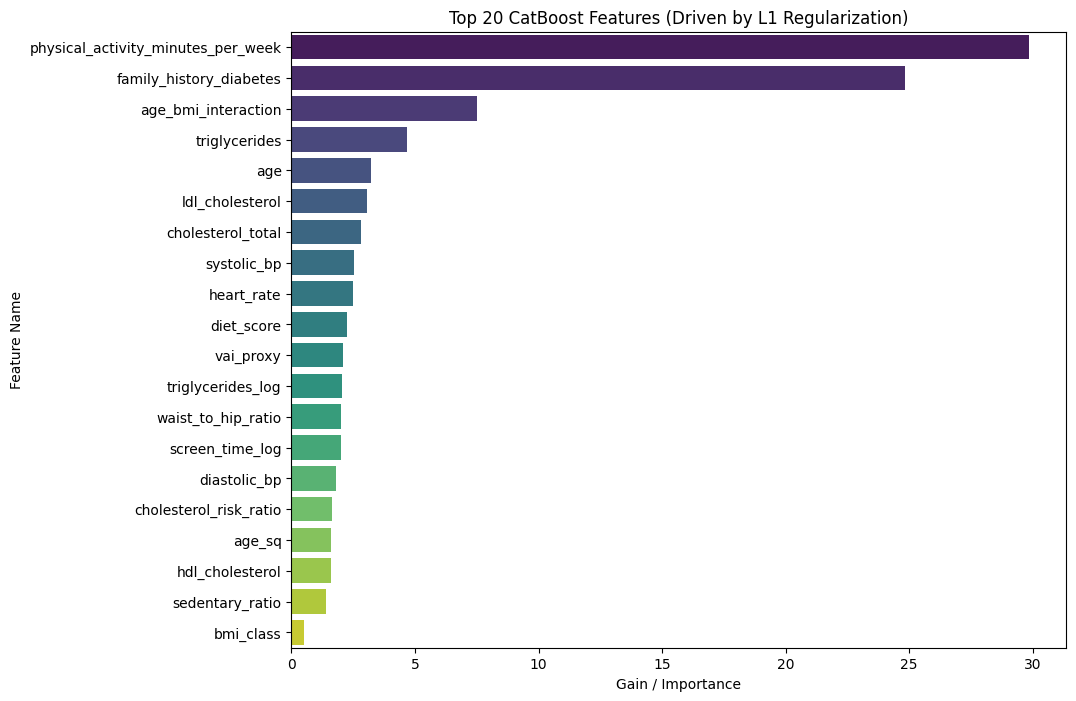

Total Features: 20
Features with > 0 Importance: 20
Features with 0 Importance (Pruned): 0


In [20]:
# Extract Importances
# 'model' is the trained XGBoost classifier from the last fold of your loop
importance = model.feature_importances_
feature_names = X_rfe.columns

# Create a DataFrame & Sort
fi_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

# Plot Top 20 Features
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=fi_df.head(20), palette='viridis')
plt.title('Top 20 CatBoost Features (Driven by L1 Regularization)')
plt.xlabel('Gain / Importance')
plt.ylabel('Feature Name')
plt.show()

# Analyze "Dead" Features
zero_imp_features = fi_df[fi_df['Importance'] == 0]
print(f"Total Features: {len(fi_df)}")
print(f"Features with > 0 Importance: {len(fi_df) - len(zero_imp_features)}")
print(f"Features with 0 Importance (Pruned): {len(zero_imp_features)}")

if len(zero_imp_features) > 0:
    print("\nExamples of Pruned Features:")
    print(zero_imp_features['Feature'].head(10).tolist())

## Prepare Submission

In [21]:
submission_df = pd.read_csv(DATA_DIR / 'sample_submission.csv')
submission_df[TARGET] = test_preds
submission_df.head(10)

,id,diagnosed_diabetes
0,700000,0.493
1,700001,0.688
2,700002,0.778
3,700003,0.400
4,700004,0.924
5,700005,0.683
6,700006,0.718
7,700007,0.937
8,700008,0.583
9,700009,0.850


In [22]:
submission_df.to_csv("submission.csv", index=False)
print("Saved: submission.csv")

Saved: submission.csv


## Save OOF and Test Predictions

In [23]:
# Save OOF predictions and raw Test predictions.
# We will load these files in a separate "Blending Notebook".
oof_df = pd.DataFrame({'id': training_df.index, 'pred_cb': oof_preds, 'target': y})
oof_df.to_csv("cb_oof_preds.csv", index=False)

test_pred_df = pd.DataFrame({'id': test_df.index, 'pred_cb': test_preds})
test_pred_df.to_csv("cb_test_preds.csv", index=False)

print("Saved for Blending: cb_oof_preds.csv, cb_test_preds.csv")

Saved for Blending: cb_oof_preds.csv, cb_test_preds.csv
